### Домашнее задание 7  

1. **Спарсите любой сайт / телеграм канал / другой текстовый источник**, на котором вы бы хотели протестировать инструменты для чанкинга — **0.5 балла**  

2. **Проведите оценку полученных текстов** — распределение длин текстов, ключевые слова и т.д.  
   Напишите выводы о полученном корпусе — **1 балл**  

3. **Протестируйте чанкеры** из chonkie, сделайте выводы о чанкерах и какие из них оказались наиболее полезными для конкретно ваших данных — **1.5 балла**  

4. **Поэкспериментируйте с ParentDocument Retriever**, сделайте вывод о применимости и как различные размеры чанков влияют на результат — **1 балл**  

5. **Попробуйте провести дополнительную обработку** чанков и/или текстов при помощи LLM (суммаризация, генерация вопросов и т.д.), сделайте выводы — **2 балла**  

**Домашнее задание необходимо предоставить в формате ссылки на Google Collab/Jupiter Notebook с вашими действиями и ключевыми выводами**  

- 6 октября 23:59 — мягкий дедлайн  
- 13 октября 23:59 — жесткий дедлайн  
- до мягкого дедлайна за работу можно получить 10 баллов, после — 5  
- работы, отправленные после 13 октября, могут быть проверены преподавателями до конца курса в формате зачет/незачет  


In [1]:
#@title Импорты
!pip install --quiet \
    telethon==1.41.2 \
    qdrant-client \
    langchain langchain-huggingface langchain-qdrant



  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 744.9/744.9 kB 18.1 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 337.3/337.3 kB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 564.3/564.3 kB 31.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.5/447.5 kB 26.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
datasets 3.6.0 requires fsspec[http]<=2025.3.0,>=2023.1.0, but you have fsspec 2025.5.1 which is incompatible.


In [2]:
!pip install --upgrade pip setuptools wheel
!pip install torch
# Стабильные версии для sentence-transformers
!pip install huggingface_hub
!pip install sentence-transformers
!pip install transformers accelerate
!pip install chonkie
!pip install tqdm


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 26.8 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 51.0 MB/s eta 0:00:00
  Attempting uninstall: setuptools
    Found existing installation: setuptools 75.2.0
    Uninstalling setuptools-75.2.0:
      Successfully uninstalled setuptools-75.2.0
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.8.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
pandas-gbq 0.29.1 requires google-api-core<3.0.0,>=2.10.2, but you have google-api-core 1.34.1 which is incompatible.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.
bigframes 2.8.0 requires google-cloud-bigque

In [3]:
!pip install pandas
!pip install matplotlib

In [4]:
import torch
print(torch.__version__)


2.6.0+cu124


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import random
import torch

random.seed(42)

from IPython.display import HTML, display

def set_css():
  display(HTML('''
  <style>
    pre {
        white-space: pre-wrap;
    }
  </style>
  '''))
#get_ipython().events.register('pre_run_cell', set_css)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [ ]:
#@title Введите ваши токены
# Вариант 2: ввод через input()
api_id = int(input("Введите API ID: "))
api_hash = input("Введите API HASH: ")
session_name = "workshop_preprocessing_v2"


1. **Спарсите любой сайт / телеграм канал / другой текстовый источник**, на котором вы бы хотели протестировать инструменты для чанкинга — **0.5 балла**  

In [7]:
#@title Запуск клиента Telegram
from telethon import TelegramClient, events, sync
from telethon.tl.types import PeerChannel

client = TelegramClient(session_name, api_id, api_hash)

In [8]:
#@title Парсинг данных
async def fetch_messages(channel_username: str, limit: int = 200):
    await client.start()
    entity = await client.get_entity(channel_username)
    msgs = []
    async for msg in client.iter_messages(entity, limit=limit):
        if msg.text is not None and msg.text != '':
            msgs.append({
                'id': msg.id,
                'date': msg.date.isoformat(),
                'text': msg.text,
            })
    await client.disconnect()
    return msgs

channel_name = 'ohmyflutter' #@param{type:"string"}
limit = 2000 #@param{type:"string"}
limit = int(limit)

out = await fetch_messages(channel_name, limit=limit)
print(f'Fetched {len(out)} messages')

Please enter your phone (or bot token):  +375295780530
Please enter the code you received:  83981


Signed in successfully as Sergey Penkovsky; remember to not break the ToS or you will risk an account ban!
Fetched 1144 messages


In [9]:
import pandas as pd

# Преобразуем список словарей в DataFrame
df = pd.DataFrame(out)

# Сохраняем в CSV
df.to_csv('./channel_name.csv', index=False, encoding='utf-8-sig')

print("Saved to messages.csv")


Saved to messages.csv


In [10]:
df = pd.read_csv(f'./channel_name.csv')
df.head()

,id,date,text
0,1201,2025-09-30T08:59:04+00:00,До Стачки осталось совсем немного времени. Под...
1,1198,2025-09-24T08:11:52+00:00,FlutterCon Europe 25 начался 🚀🚀🚀\nКстати орган...
2,1197,2025-09-19T14:29:48+00:00,"Итак, розыгрыш ""несуществующих билетов"" для сб..."
3,1196,2025-09-19T12:32:18+00:00,Очередной выпуск Observable Flutter посвящён р...
4,1195,2025-09-17T11:51:03+00:00,В этот раз на “Стачке” Flutter-у будет посвяще...


2. **Проведите оценку полученных текстов** — распределение длин текстов, ключевые слова и т.д.  
   Напишите выводы о полученном корпусе — **1 балл**  

In [11]:
df.head(5)

,id,date,text
0,1201,2025-09-30T08:59:04+00:00,До Стачки осталось совсем немного времени. Под...
1,1198,2025-09-24T08:11:52+00:00,FlutterCon Europe 25 начался 🚀🚀🚀\nКстати орган...
2,1197,2025-09-19T14:29:48+00:00,"Итак, розыгрыш ""несуществующих билетов"" для сб..."
3,1196,2025-09-19T12:32:18+00:00,Очередной выпуск Observable Flutter посвящён р...
4,1195,2025-09-17T11:51:03+00:00,В этот раз на “Стачке” Flutter-у будет посвяще...


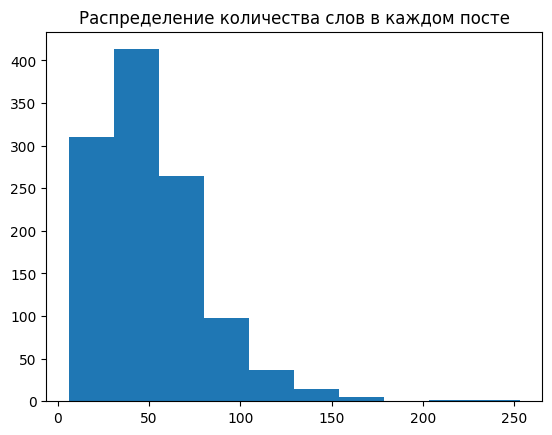

In [12]:
df['word_count'] = df['text'].fillna('').str.split().str.len()

plt.hist(df['word_count'].values)
plt.title("Распределение количества слов в каждом посте");

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1144 entries, 0 to 1143
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id          1144 non-null   int64 
 1   date        1144 non-null   object
 2   text        1144 non-null   object
 3   word_count  1144 non-null   int64 
dtypes: int64(2), object(2)
memory usage: 35.9+ KB


In [14]:
df.describe()

,id,word_count
count,1144.000000,1144.000000
mean,601.756119,51.038462
std,350.152696,29.419676
min,4.000000,6.000000
25%,296.750000,29.000000
50%,592.500000,46.000000
75%,912.250000,66.250000
max,1201.000000,253.000000


In [15]:
shortest = df[df['word_count'] < 100].sample(5, random_state=42)['text'].values

for i, text in enumerate(shortest):
    print(f"Пост номер {i + 1}: {text}")
    print()

Пост номер 1: Стартовал ежегодный опрос исследование про состояние отечественного рынка мобильной разработки. Основные темы, которым посвящен опрос:

👉 Популярные источники новых знаний;
👉 Интересные конференции мобильных разработчиков;
👉 Команды мобильной разработки, какие более всех заметны и интересны.

Пройти [опрос](https://forms.gle/g2tRE4j9cW9grWrp8) можно по ссылке, а через месяц будут опубликованы результаты.

#опрос

Пост номер 2: В очередном [Widget of the Week](https://go.surf.ru/hr/flutter/ohmyflutter/wotw-statefulbuilder), команда Flutter показала StatefulBuilder. Наверное его появление имеет некоторое рациональное объяснение для упрощения пересборки конкретных частей поддерева, но все же, не советовал бы так делать - лучше хорошо декомпозируйте и проводите разбиение по смыслу и будет в вашем приложении счастье и без всяких StatefulBuilder 😉

#WidgetoftheWeek

Пост номер 3: [​](https://telegra.ph/file/b5529bd592f0574f3abe6.mp4)Надоело держать на компьютере множество эмуля

In [16]:
longest = df[df['word_count'] > 100].sample(5, random_state=42)['text'].values

for i, text in enumerate(longest):
    print(f"Пост номер {i + 1}: {text}")
    print("==========================")

Пост номер 1: Dart активно используется не только во Flutter приложениях. В том числе его можно неплохо использовать и в разработке backend. Уже существуют довольно удобные фреймворки и появляются новые. Недавно наткнулся на статью, разработчика Mehmet Yaz, который занимается разработкой своего фреймворка, под названием Style. Интересным моментом лично для меня в нем является попытка построить backend фреймворк в похожем на Flutter стиле. К тому же проект находится в активной стадии разработки и автор просит фидбек на то, что у него получается, поэтому вы можете сделать свой вклад в развитие, если идея придется вам по душе, как минимум дав ему обратную связь.

📌 Почитать подробнее, можно в [статье](http://go.surf.ru/с/flutter/ohmyflutter/style-backend-framework).

#статья
Пост номер 2: В этот раз на “Стачке” Flutter-у будет посвящена целая отдельная секция – FlutterConf. В ней организаторы обещают:

👉 Архитектура и кейсы: Фокус на построении надежных и масштабируемых архитектур в реаль

In [17]:
import pandas as pd
import re
from collections import Counter
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Загружаем датасет
texts = df["text"].dropna().tolist()

# 2. Очистка текста
def preprocess(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)  # удалить ссылки
    text = re.sub(r"[^\w\s#]", " ", text)  # убрать пунктуацию, оставить слова и #
    return text

clean_texts = [preprocess(t) for t in texts]

# 3. Частотность слов
stop_words = set(stopwords.words("russian")) | set(stopwords.words("english"))

tokens = []
for text in clean_texts:
    for word in text.split():
        if word not in stop_words and len(word) > 2:
            tokens.append(word)

freq = Counter(tokens)
print("\n🔹 Топ-20 частотных слов:")
print(freq.most_common(20))

# 4. TF-IDF
vectorizer = TfidfVectorizer(max_features=20, stop_words=list(stop_words))
X = vectorizer.fit_transform(clean_texts)

print("\n🔹 Топ-20 слов по TF-IDF:")
print(vectorizer.get_feature_names_out())



🔹 Топ-20 частотных слов:
[('flutter', 1076), ('ссылке', 458), ('это', 318), ('статье', 294), ('dart', 260), ('подробности', 178), ('#статья', 168), ('приложения', 167), ('видео', 155), ('#ohmyteam', 144), ('#ohmyfedukenukem', 144), ('подробнее', 136), ('#article', 124), ('google', 114), ('довольно', 113), ('работы', 103), ('который', 100), ('статья', 99), ('найти', 98), ('использовать', 96)]

🔹 Топ-20 слов по TF-IDF:
['article' 'dart' 'flutter' 'google' 'ohmyfedukenukem' 'ohmyteam' 'видео'
 'довольно' 'использовать' 'который' 'найти' 'обновление' 'подробнее'
 'подробности' 'приложения' 'работы' 'ссылке' 'статье' 'статья' 'это']


## Общие выводы по dataset


## 📊 Распределение длин текстов

* **Среднее количество слов:** ~51
* **Медиана:** 46 слов
* **Стандартное отклонение:** ~29 слов
* **Минимум:** 6 слов
* **Максимум:** 253 слова

🔎 **Выводы:**

* Большинство постов короткие (20–60 слов).
* Есть «длинный хвост» постов более чем на 100 слов, но их относительно мало.
* По гистограмме видно, что распределение скошено влево: основная масса сконцентрирована в районе 30–60 слов, а тексты длиннее 100 слов — редкость.

---

## 🗝️ Ключевые слова

* **Частотные (по подсчёту слов):**

  * `flutter`, `dart`, `ссылке`, `статье`, `подробности`, `приложения`, `видео`
  * часто встречаются хэштеги: `#article`, `#ohmyteam`, `#ohmyfedukenukem`
* **TF-IDF (более «содержательные»):**

  * `flutter`, `dart`, `google`, `article`, `приложения`, `обновление`, `видео`, `использовать`, `найти`, `работы`.

🔎 **Выводы:**

* Корпус в первую очередь посвящён **Flutter** и **Dart**.
* Большая часть постов — **новости, статьи, видео, анонсы событий**.
* Хэштеги используются для навигации внутри канала.

---

## 📝 Общая характеристика корпуса

1. **Тематика:** образовательный и новостной контент по Flutter/Dart, обзоры инструментов, ссылки на видео и статьи.
2. **Структура текстов:**

   * посты довольно короткие;
   * содержат эмодзи и ссылки;
   * часто встречаются хэштеги в конце поста.
3. **Лексика:** много технических терминов, упоминаний экосистемы Google, названий инструментов и библиотек.

---

✅ **Итог:**
Корпус представляет собой компактные посты (в среднем ~50 слов), ориентированные на аудиторию Flutter-разработчиков. В текстах доминируют слова «flutter», «dart», «статья», «ссылке», «видео», что подтверждает их образовательный и новостной характер. Распределение длин текстов неравномерное: преобладают короткие заметки (20–60 слов), а длинные материалы встречаются редко.

3. **Протестируйте чанкеры** из chonkie, сделайте выводы о чанкерах и какие из них оказались наиболее полезными для конкретно ваших данных — **1.5 балла**  

In [18]:
#скачаем, если нужно
!pip install chonkie

In [19]:
from chonkie import TokenChunker, SentenceChunker, RecursiveChunker, RecursiveRules, SemanticChunker

**`TokenChunker`:**

Самый простой чанкер, который разобьёт текст ровно по токенам; поддерживает overlap (пересечение чанков). Это хорошо, когда нам нужен чёткий контроль токенов и его количества, особенно если мы хотим контролировать расходы, работая со внешними нейросетями, однако мы можем потерять часть смысла, разрезав слово на две части.

Подробную документацию можно почитать тут: [TokenChunker](https://docs.chonkie.ai/python-sdk/chunkers/token-chunker)

In [20]:
token_chunker = TokenChunker(
    tokenizer="sergeyzh/rubert-mini-frida",
    chunk_size=50,
    chunk_overlap=16
)

tokenizer.json: 0.00B [00:00, ?B/s]

In [21]:
shortest_chunked = token_chunker.chunk_batch(shortest)

print()
for i, text in enumerate(shortest_chunked):
    print(f"Текст номер {i + 1}:")
    for chunk in text:
        print(f"Размер чанка: {chunk.token_count}")
        print(f"Текст чанка: {chunk.text}")
        print()
    print("="*20)

🦛 choooooooooooooooooooonk 100% • 5/5 batches chunked [00:00<00:00, 538.17batch/s] 🌱


Текст номер 1:
Размер чанка: 50
Текст чанка: Стартовал ежегодный опрос исследование про состояние отечественного рынка мобильной разработки. Основные темы, которым посвящен опрос : Популярные источники новых знаний ; Интересные конференции мобильных разработчиков ; Команды мобильной разработки, какие более всех заметны и интересны. Пройти [ опрос

Размер чанка: 50
Текст чанка: Команды мобильной разработки, какие более всех заметны и интересны. Пройти [ опрос ] ( https : / / forms. gle / g2tRE4j9cW9grWrp8 ) можно по ссылке, а через месяц будут

Размер чанка: 22
Текст чанка: ##cW9grWrp8 ) можно по ссылке, а через месяц будут опубликованы результаты. # опрос

Текст номер 2:
Размер чанка: 50
Текст чанка: В очередном [ Widget of the Week ] ( https : / / go. surf. ru / hr / flutter / ohmyflutter / wotw - statefulbuilder ), команда Flutter показала

Размер чанка: 50
Текст чанка: / wotw - statefulbuilder ), команда Flutter показала StatefulBuilder. Наверное его появление имеет некоторое рацио

In [22]:
longest_chunked = token_chunker.chunk_batch(longest)

print()
for i, text in enumerate(longest_chunked):
    print(f"Текст номер {i + 1}:")
    for chunk in text:
        print(f"Размер чанка: {chunk.token_count}")
        print(f"Текст чанка: {chunk.text}")
        print()
    print("="*20)

🦛 choooooooooooooooooooonk 100% • 5/5 batches chunked [00:00<00:00, 635.13batch/s] 🌱


Текст номер 1:
Размер чанка: 50
Текст чанка: Dart активно используется не только во Flutter приложениях. В том числе его можно неплохо использовать и в разработке backend. Уже существуют довольно удобные фреймворки и появляются новые. Недавно наткнулся на статью, разработчика Mehmet Yaz, который

Размер чанка: 50
Текст чанка: появляются новые. Недавно наткнулся на статью, разработчика Mehmet Yaz, который занимается разработкой своего фреймворка, под названием Style. Интересным моментом лично для меня в нем является попытка построить backend фреймворк в похожем на Flutter

Размер чанка: 50
Текст чанка: нем является попытка построить backend фреймворк в похожем на Flutter стиле. К тому же проект находится в активной стадии разработки и автор просит фидбек на то, что у него получается, поэтому вы можете сделать свой вклад в развитие, если

Размер чанка: 50
Текст чанка: , что у него получается, поэтому вы можете сделать свой вклад в развитие, если идея придется вам по душе, как минимум да

**`SentenceChunker`**:

Этот чанкер обрезает по границам предложения, собирая предложения, пока мы не достигнем целевого размера. Таким образом мы сохраняем целостность одной мысли, не разрезая предложения, как в чанкере выше. Тем не менее, проблема разделения смысла остаётся, так как он может быть размазан по нескольким предложениям, а чанки могут получиться неконсистентными (одни покороче, другие подлиннее) -- из-за этого может быть тяжело следить за количеством токенов, попадающих в модель, а потому может быть тяжелее отслеживать биллинг.

Такой чанкер будет хорош для текстов, где каждое предложение является более-менее оконченной мыслью, преложения либо короткие, либо хотя бы примерно одного размера (не стоит использовать для чанкирования "Войны и Мира"). Кроме того, иногда имеет смысл иметь fallback на случай превышения общего размера токенов, которые мы куда-то передаём (например, топ-5 чанков передаём в LLM)

Документацию можно глянуть тут: [Sentence Chunker](https://docs.chonkie.ai/python-sdk/chunkers/sentence-chunker)

In [23]:
token_chunker = SentenceChunker(
    tokenizer_or_token_counter="sergeyzh/rubert-mini-frida",
    chunk_size=50,
    chunk_overlap=16
)

In [24]:
shortest_chunked = token_chunker.chunk_batch(shortest)

print()
for i, text in enumerate(shortest_chunked):
    print(f"Текст номер {i + 1}:")
    for chunk in text:
        print(f"Размер чанка: {chunk.token_count}")
        print(f"Текст чанка: {chunk.text}")
        print()
    print("="*20)

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
🦛 choooooooooooooooooooonk 1


Текст номер 1:
Размер чанка: 12
Текст чанка: Стартовал ежегодный опрос исследование про состояние отечественного рынка мобильной разработки. 

Размер чанка: 7
Текст чанка: Основные темы, которым посвящен опрос:


Размер чанка: 7
Текст чанка: 
👉 Популярные источники новых знаний;


Размер чанка: 7
Текст чанка: 👉 Интересные конференции мобильных разработчиков;


Размер чанка: 12
Текст чанка: 👉 Команды мобильной разработки, какие более всех заметны и интересны.


Размер чанка: 41
Текст чанка: 
Пройти [опрос](https://forms.gle/g2tRE4j9cW9grWrp8) можно по ссылке, а через месяц будут опубликованы результаты.


Размер чанка: 2
Текст чанка: 
#опрос

Текст номер 2:
Размер чанка: 55
Текст чанка: В очередном [Widget of the Week](https://go.surf.ru/hr/flutter/ohmyflutter/wotw-statefulbuilder), команда Flutter показала StatefulBuilder. 

Размер чанка: 58
Текст чанка: Наверное его появление имеет некоторое рациональное объяснение для упрощения пересборки конкретных частей поддерева, но все же, не с

In [25]:
longest_chunked = token_chunker.chunk_batch(longest)

print()
for i, text in enumerate(longest_chunked):
    print(f"Текст номер {i + 1}:")
    for chunk in text:
        print(f"Размер чанка: {chunk.token_count}")
        print(f"Текст чанка: {chunk.text}")
        print()
    print("="*20)

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
🦛 choooooooooooooooooooonk 1


Текст номер 1:
Размер чанка: 12
Текст чанка: Dart активно используется не только во Flutter приложениях. 

Размер чанка: 13
Текст чанка: В том числе его можно неплохо использовать и в разработке backend. 

Размер чанка: 11
Текст чанка: Уже существуют довольно удобные фреймворки и появляются новые. 

Размер чанка: 24
Текст чанка: Недавно наткнулся на статью, разработчика Mehmet Yaz, который занимается разработкой своего фреймворка, под названием Style. 

Размер чанка: 25
Текст чанка: Интересным моментом лично для меня в нем является попытка построить backend фреймворк в похожем на Flutter стиле. 

Размер чанка: 45
Текст чанка: К тому же проект находится в активной стадии разработки и автор просит фидбек на то, что у него получается, поэтому вы можете сделать свой вклад в развитие, если идея придется вам по душе, как минимум дав ему обратную связь.


Размер чанка: 42
Текст чанка: 
📌 Почитать подробнее, можно в [статье](http://go.surf.ru/с/flutter/ohmyflutter/style-backend-framework).




**`SemantcicChunker`**:

Сохраняем смыслы внутри чанка: делим так, чтобы (по возможности) один смысл == один чанк. Группируем соседние элементы до тех пор, пока внутри семантическая когерентность высокая.

Чанки согласованы семантически -> лучше семантический ретрив; меньше шумных/неинформативных чанков.

В недавних обновлениях библиотеки добавили объединение даже не-соседствующих кусков, и теперь для этого нужно для этого изменить параметр `skip_window` (`0`: склеиваем только последовательные, `1`: группируем разрозненные). Это наследие метода `SDPMChunker` (Semantic Double-Pass Merge), который был убран в недавнем обновлении библиотеки. Если вам важно соседство частей, обратите внимание на этот параметр.

Таким образом, можно использовать этот метод для длинных разнотемных текстов, где темы/подтемы переплетаются (отчёты, форумы, собранные логи, образовательные статьи).

Документация лежит [тут](https://docs.chonkie.ai/python-sdk/chunkers/semantic-chunker).

In [26]:
token_chunker = SemanticChunker(
    embedding_model="sergeyzh/rubert-mini-frida",
    threshold=0.5,                   # Similarity threshold (0-1) or (1-100) or "auto"
    chunk_size=50,
    min_sentences=1                  # Минимальный размер чанка (в предложениях)
)

2025-10-01 03:50:59.444409: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1759290659.636816      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1759290659.694013      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


modules.json:   0%|          | 0.00/368 [00:00<?, ?B/s]

config_sentence_transformers.json: 0.00B [00:00, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/129M [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/732 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/196 [00:00<?, ?B/s]

In [27]:
shortest_chunked = token_chunker.chunk_batch(shortest)

print()
for i, text in enumerate(shortest_chunked):
    print(f"Текст номер {i + 1}:")
    for chunk in text:
        print(f"Размер чанка: {chunk.token_count}")
        print(f"Текст чанка: {chunk.text}")
        print()
    print("="*20)

🦛 ch                    nk   0% • 0/5 docs chunked [00:00<?, ?doc/s] 🌱

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

🦛 choooo                nk  20% • 1/5 docs chunked [00:00<00:02,  1.96doc/s] 🌱

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

...

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

🦛 choooooooooooooooooooonk 100% • 5/5 docs chunked [00:00<00:00,  7.71doc/s] 🌱


Текст номер 1:
Размер чанка: 45
Текст чанка: Стартовал ежегодный опрос исследование про состояние отечественного рынка мобильной разработки. Основные темы, которым посвящен опрос:

👉 Популярные источники новых знаний;
👉 Интересные конференции мобильных разработчиков;
👉 Команды мобильной разработки, какие более всех заметны и интересны.


Размер чанка: 43
Текст чанка: 
Пройти [опрос](https://forms.gle/g2tRE4j9cW9grWrp8) можно по ссылке, а через месяц будут опубликованы результаты.

#опрос

Текст номер 2:
Размер чанка: 120
Текст чанка: В очередном [Widget of the Week](https://go.surf.ru/hr/flutter/ohmyflutter/wotw-statefulbuilder), команда Flutter показала StatefulBuilder. Наверное его появление имеет некоторое рациональное объяснение для упрощения пересборки конкретных частей поддерева, но все же, не советовал бы так делать - лучше хорошо декомпозируйте и проводите разбиение по смыслу и будет в вашем приложении счастье и без всяких StatefulBuilder 😉

#WidgetoftheWeek

Текст номер 3:
Ра

In [28]:
longest_chunked = token_chunker.chunk_batch(longest)

print()
for i, text in enumerate(longest_chunked):
    print(f"Текст номер {i + 1}:")
    for chunk in text:
        print(f"Размер чанка: {chunk.token_count}")
        print(f"Текст чанка: {chunk.text}")
        print()
    print("="*20)

🦛 ch                    nk   0% • 0/5 docs chunked [00:00<?, ?doc/s] 🌱

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

...

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

🦛 choooooooooooooooooooonk 100% • 5/5 docs chunked [00:00<00:00, 21.41doc/s] 🌱


Текст номер 1:
Размер чанка: 36
Текст чанка: Dart активно используется не только во Flutter приложениях. В том числе его можно неплохо использовать и в разработке backend. Уже существуют довольно удобные фреймворки и появляются новые. 

Размер чанка: 49
Текст чанка: Недавно наткнулся на статью, разработчика Mehmet Yaz, который занимается разработкой своего фреймворка, под названием Style. Интересным моментом лично для меня в нем является попытка построить backend фреймворк в похожем на Flutter стиле. 

Размер чанка: 45
Текст чанка: К тому же проект находится в активной стадии разработки и автор просит фидбек на то, что у него получается, поэтому вы можете сделать свой вклад в развитие, если идея придется вам по душе, как минимум дав ему обратную связь.


Размер чанка: 42
Текст чанка: 
📌 Почитать подробнее, можно в [статье](http://go.surf.ru/с/flutter/ohmyflutter/style-backend-framework).


Размер чанка: 2
Текст чанка: 
#статья

Текст номер 2:
Размер чанка: 31
Текст чанка: В этот раз н

**`RecursiveChunker`**:

Метод разбивает документ по иерархическим уровням (заголовки → параграфы → предложения → токены). Плюс: сохраняет структуру и семантические границы; минус: требует правил для разных форматов и чуть сложнее поддерживать. Используйте для технических доков, markdown/HTML, книг и любых структурированных текстов. Удобно, если формат неизменен, потому что иначе правила могут заскейлиться некорректно или быть неудобными для конкретного формата текста.

Вместе с тем, очевидно, что чанкер не делит текст на куски хоть сколько-то консистентных размеров, так что лучше иметь fallback'и на превышение размера контекстов.

Документацию о RecursiveChunker можно почитать [тут](https://docs.chonkie.ai/python-sdk/chunkers/recursive-chunker), а о правилах [тут](https://docs.chonkie.ai/python-sdk/chunkers/recursive-chunker#additional-information)


In [29]:
from chonkie import RecursiveRules, RecursiveChunker

token_chunker = RecursiveChunker(
    tokenizer_or_token_counter="sergeyzh/rubert-mini-frida",
    chunk_size=50,
    rules=RecursiveRules(),
    min_characters_per_chunk=24,
)

In [30]:
shortest_chunked = token_chunker.chunk_batch(shortest)

print()
for i, text in enumerate(shortest_chunked):
    print(f"Текст номер {i + 1}:")
    for chunk in text:
        print(f"Размер чанка: {chunk.token_count}")
        print(f"Текст чанка: {chunk.text}")
        print()
    print("="*20)

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
🦛 choooooooooooooooooooonk 1


Текст номер 1:
Размер чанка: 45
Текст чанка: Стартовал ежегодный опрос исследование про состояние отечественного рынка мобильной разработки. Основные темы, которым посвящен опрос:

👉 Популярные источники новых знаний;
👉 Интересные конференции мобильных разработчиков;
👉 Команды мобильной разработки, какие более всех заметны и интересны.


Размер чанка: 43
Текст чанка: 
Пройти [опрос](https://forms.gle/g2tRE4j9cW9grWrp8) можно по ссылке, а через месяц будут опубликованы результаты.

#опрос

Текст номер 2:
Размер чанка: 37
Текст чанка: В очередном [Widget of the Week](https://go.surf.ru/hr/flutter/ohmyflutter/wotw-

Размер чанка: 18
Текст чанка: statefulbuilder), команда Flutter показала StatefulBuilder. 

Размер чанка: 29
Текст чанка: Наверное его появление имеет некоторое рациональное объяснение для упрощения пересборки конкретных частей поддерева, но все же, не советовал бы так делать -

Размер чанка: 29
Текст чанка:  лучше хорошо декомпозируйте и проводите разбиение по смыслу и будет

In [31]:
longest_chunked = token_chunker.chunk_batch(longest)

print()
for i, text in enumerate(longest_chunked):
    print(f"Текст номер {i + 1}:")
    for chunk in text:
        print(f"Размер чанка: {chunk.token_count}")
        print(f"Текст чанка: {chunk.text}")
        print()
    print("="*20)

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
🦛 choooooooooooooooooooonk 1


Текст номер 1:
Размер чанка: 36
Текст чанка: Dart активно используется не только во Flutter приложениях. В том числе его можно неплохо использовать и в разработке backend. Уже существуют довольно удобные фреймворки и появляются новые. 

Размер чанка: 49
Текст чанка: Недавно наткнулся на статью, разработчика Mehmet Yaz, который занимается разработкой своего фреймворка, под названием Style. Интересным моментом лично для меня в нем является попытка построить backend фреймворк в похожем на Flutter стиле. 

Размер чанка: 45
Текст чанка: К тому же проект находится в активной стадии разработки и автор просит фидбек на то, что у него получается, поэтому вы можете сделать свой вклад в развитие, если идея придется вам по душе, как минимум дав ему обратную связь.


Размер чанка: 44
Текст чанка: 
📌 Почитать подробнее, можно в [статье](http://go.surf.ru/с/flutter/ohmyflutter/style-backend-framework).

#статья

Текст номер 2:
Размер чанка: 31
Текст чанка: В этот раз на “Стачке” Flutter-у будет посв

Можно достать рекурсивный чанкер из готовых рецептов для разной разметки и разных языков, например, вот тут мы загружаем готовый рецепт на markdown разметку:

In [32]:
!pip install "chonkie[hub]"


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


In [33]:
token_chunker = RecursiveChunker.from_recipe("markdown")

v1.schema.json: 0.00B [00:00, ?B/s]

markdown_en.json: 0.00B [00:00, ?B/s]

In [34]:
shortest_chunked = token_chunker.chunk_batch(shortest)

print()
for i, text in enumerate(shortest_chunked):
    print(f"Текст номер {i + 1}:")
    for chunk in text:
        print(f"Размер чанка: {chunk.token_count}")
        print(f"Текст чанка: {chunk.text}")
        print()
    print("="*20)

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
🦛 choooooooooooooooooooonk 1


Текст номер 1:
Размер чанка: 415
Текст чанка: Стартовал ежегодный опрос исследование про состояние отечественного рынка мобильной разработки. Основные темы, которым посвящен опрос:

👉 Популярные источники новых знаний;
👉 Интересные конференции мобильных разработчиков;
👉 Команды мобильной разработки, какие более всех заметны и интересны.

Пройти [опрос](https://forms.gle/g2tRE4j9cW9grWrp8) можно по ссылке, а через месяц будут опубликованы результаты.

#опрос

Текст номер 2:
Размер чанка: 440
Текст чанка: В очередном [Widget of the Week](https://go.surf.ru/hr/flutter/ohmyflutter/wotw-statefulbuilder), команда Flutter показала StatefulBuilder. Наверное его появление имеет некоторое рациональное объяснение для упрощения пересборки конкретных частей поддерева, но все же, не советовал бы так делать - лучше хорошо декомпозируйте и проводите разбиение по смыслу и будет в вашем приложении счастье и без всяких StatefulBuilder 😉

#WidgetoftheWeek

Текст номер 3:
Размер чанка: 751
Текст чанка: [​

In [35]:
longest_chunked = token_chunker.chunk_batch(longest)

print()
for i, text in enumerate(longest_chunked):
    print(f"Текст номер {i + 1}:")
    for chunk in text:
        print(f"Размер чанка: {chunk.token_count}")
        print(f"Текст чанка: {chunk.text}")
        print()
    print("="*20)

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
🦛 choooooooooooooooooooonk 1


Текст номер 1:
Размер чанка: 768
Текст чанка: Dart активно используется не только во Flutter приложениях. В том числе его можно неплохо использовать и в разработке backend. Уже существуют довольно удобные фреймворки и появляются новые. Недавно наткнулся на статью, разработчика Mehmet Yaz, который занимается разработкой своего фреймворка, под названием Style. Интересным моментом лично для меня в нем является попытка построить backend фреймворк в похожем на Flutter стиле. К тому же проект находится в активной стадии разработки и автор просит фидбек на то, что у него получается, поэтому вы можете сделать свой вклад в развитие, если идея придется вам по душе, как минимум дав ему обратную связь.

📌 Почитать подробнее, можно в [статье](http://go.surf.ru/с/flutter/ohmyflutter/style-backend-framework).

#статья

Текст номер 2:
Размер чанка: 866
Текст чанка: В этот раз на “Стачке” Flutter-у будет посвящена целая отдельная секция – FlutterConf. В ней организаторы обещают:

👉 Архитектура и кейсы

Полный список рецептов можно глянуть [тут](https://huggingface.co/datasets/chonkie-ai/recipes).

## Общий вывод по chunker


## 🔍 Результаты работы `TokenChunker`

### На коротких текстах

* Посты длиной до ~50 токенов нарезаются **на 1–2 чанка**, иногда остаётся маленький «хвост» (22 токена в примере).
* Из-за фиксированного размера чанка (50 токенов) и overlap (16) иногда видна **частичная избыточность** — куски пересекаются и содержат повторы.
* Для коротких текстов TokenChunker не даёт особой пользы: смысловой нагрузки мало, а дробление может даже мешать.

### На длинных текстах

* Длинный пост был аккуратно нарезан на чанки по 50 токенов, сохраняя связность.
* В отличие от SentenceChunker или SemanticChunker (которые режут по смысловым границам), TokenChunker нарезает **механически** — без учёта предложений или абзацев.
* Это гарантирует, что длина чанков всегда в рамках модели, но иногда фразы оказываются разрезанными.


## 🔍 Результаты SentenceChunker

### На коротких текстах

* Текст был разбит **по предложениям и смысловым кускам**, а не механически.
* Видно, что даже эмодзи-списки (👉) и хэштеги (`#опрос`) остались отдельными чанками.
* Получились компактные блоки (от 2 до 41 токена), которые легко воспринимаются моделью.
* Нет дублирования, как у TokenChunker (где overlap порождал почти одинаковые куски).

### На длинных текстах

* Каждый абзац/предложение аккуратно выделен.
* Сохраняется логика: сначала введение, затем развитие мысли, потом ссылка и хэштег отдельно.
* Размеры чанков варьируются (11–45 токенов), что делает их более **естественными**, но может быть **слишком мелко** для некоторых задач (например, эмбеддинги на предложениях иногда хуже, чем на абзацах).


## 🔍 Результаты SemanticChunker

### На коротком тексте

* Вместо того чтобы дробить каждый список/предложение (как SentenceChunker), **SemanticChunker сгруппировал смысловые блоки**:

  * Первый чанк = ввод + три пункта опроса.
  * Второй чанк = инструкция + ссылка + хэштег.
* Итог: получились **логически завершённые абзацы**, что особенно удобно для эмбеддингов и поиска по смыслу.

### На длинном тексте

* Чанки сформированы **по темам**, а не просто по предложениям:

  * 1️⃣ Введение + объяснение, зачем нужен Dart в backend.
  * 2️⃣ Статья и описание фреймворка.
  * 3️⃣ Призыв к фидбеку.
  * 4️⃣ Ссылка на статью.
  * 5️⃣ Хэштег отдельно.
* Размер чанков (36–49 токенов) хорошо держится в рамках лимита, при этом **сохраняется связность**.

## 🔍 Результаты RecursiveChunker

### На коротком тексте

* Получилось **2 чанка**:

  * Первый объединяет ввод и все пункты списка.
  * Второй — ссылка и хэштег.
* Очень похоже на SemanticChunker, но работает **без эмбеддингов** — правилами.

### На длинном тексте

* Разбивка совпадает с **логическими абзацами**:
  1️⃣ Введение про Dart и backend.
  2️⃣ Статья и фреймворк Style.
  3️⃣ Призыв к фидбеку.
  4️⃣ Ссылка и хэштег.
* Отличается от SentenceChunker тем, что **не дробит по каждому предложению**, а старается собрать блок побольше, но при этом **не превышает лимит токенов**.

---

## ⚖️ Сравнение Chunker

| Чанкер               | Особенность                                             | На коротком                           | На длинном                |
| -------------------- | ------------------------------------------------------- | ------------------------------------- | ------------------------- |
| **TokenChunker**     | Чисто токены, режет жёстко                              | Разрывы внутри предложений            | Куски равного размера     |
| **SentenceChunker**  | Деление по предложениям                                 | Сохраняет структуру, но слишком мелко | Много маленьких кусков    |
| **SemanticChunker**  | Деление по смыслу (эмбеддинги)                          | Логично сгруппировал                  | Абзацы + семантика        |
| **RecursiveChunker** | Иерархические правила (параграф → предложение → токены) | Чёткие блоки                          | Хорошая структура абзацев |

---

## ✅ Вывод

* **RecursiveChunker** показывает себя **лучше, чем SentenceChunker** и **сравнимо с SemanticChunker**, но при этом **без лишней нагрузки от эмбеддингов**.
* Для корпуса с постами в стиле Telegram (где часто: ввод → список → ссылка → хэштег):

  * **RecursiveChunker** = оптимальный выбор, если нужна **просто чистая и логичная сегментация**.
  * **SemanticChunker** = лучше, если далее будет **поиск по смыслу или семантическая кластеризация**.
* RecursiveChunker можно рассматривать как **универсальный дефолтный вариант**: он и аккуратный, и лёгкий, и хорошо работает на разных типах текстов.


# Попробуем имплементировать это в поиск

In [36]:
#@title Немного магии для работы поиска

from langchain_huggingface import HuggingFaceEmbeddings
from langchain_qdrant import Qdrant
from langchain_core.documents import Document

embed_model_name = "sergeyzh/rubert-mini-frida"
embed_model_kwargs = {'device': device}
embed_encode_kwargs = {'normalize_embeddings': True}
query_encode_kwargs = None

embeddings = HuggingFaceEmbeddings(
    model_name=embed_model_name,
    model_kwargs=embed_model_kwargs,
    encode_kwargs=embed_encode_kwargs,
)

documents = [Document(page_content=text) for text in df.text.values]

qdrant = Qdrant.from_documents(
            documents,
            embeddings,
            location=":memory:",
            collection_name="documents",
)

qdrant_retriever = qdrant.as_retriever(verbose=True)

Начнём с пары простых запросов, в которых мы никак не меняли размер документов, и грузили как есть:

In [37]:
query = "Flutter"
retrieved_docs = [document.page_content for document in qdrant_retriever.get_relevant_documents(query)]

print(f"По запросу {query} нашлось:")
for i, text in enumerate(retrieved_docs):
    print(f"Пост номер {i + 1}: {text}")
    print("==========================")

По запросу Flutter нашлось:
Пост номер 1: Работа Flutter строится на множестве довольно важных концептов, каждый из которых решает определенную проблему.

📌 Почитать подробнее можно в [статье](https://docs.flutter.dev/resources/inside-flutter) в официальной документации.

#documentation
Пост номер 2: В продолжении темы accessibility, о том как работает поддержка специальных возможностей для Flutter Web в статье от Thomas Steiner.

📌 Подробности по ссылке.
https://medium.com/flutter/accessibility-in-flutter-on-the-web-51bfc558b7d3

#article
Пост номер 3: Компания Омертекс ищет Flutter-разработчика. 

**Обязанности:**
Проект в активной фазе, нужно перенести на Flutter

**Заработная плата (₽):**
договорная

**Контакт для связи:** @nziatikova

Подробности от работодателя в первом комментарии.
Пост номер 4: На днях команда Flutter анонсировала старт первого ежеквартального опроса. С помощью этих опросов команда Fluter собирает актуальный фидбек о работе фреймворка и выбирает направления раз

/tmp/ipykernel_36/2728290977.py:2: LangChainDeprecationWarning: The method `BaseRetriever.get_relevant_documents` was deprecated in langchain-core 0.1.46 and will be removed in 1.0. Use :meth:`~invoke` instead.
  retrieved_docs = [document.page_content for document in qdrant_retriever.get_relevant_documents(query)]


In [38]:
query = "кто ищет Flutter-разработчика?"
retrieved_docs = [document.page_content for document in qdrant_retriever.get_relevant_documents(query)]

print(f"По запросу {query} нашлось:\n")
for i, text in enumerate(retrieved_docs):
    print(f"Пост номер {i + 1}: {text}")
    print("==========================")
    print()

По запросу кто ищет Flutter-разработчика? нашлось:

Пост номер 1: Компания **Paynocchio** ищет Flutter - разработчика

**Обязанности:**
- Разработка мобильных приложений с использованием Flutter
- Создание красивых и интуитивно понятных пользовательских интерфейсов
- Интеграция мобильных приложений с серверной частью и API
- Оптимизация производительности и масштабируемости приложений
- Участие в обсуждении архитектуры и дизайна проектов
- Тестирование и исправление ошибок

**Заработная плата (₽):**
300 000 рублей на руки 

**Контакт для связи: **
@YuliaValiulina

Подробности от работодателя в комментариях к посту

Пост номер 2: Компания Magnus Tech ищет Flutter-разработчика.

**Обязанности:**
– Разработка кросс-платформенных мобильных приложений на фреймворке Google Flutter;
– Разработка платформенно-зависимых расширений для Google Flutter (в случае отсутствия оберток для Flutter);
– Интеграция с бэкэндом.

**Заработная плата (₽):**
До 250 тысяч рублей на руки

**Контакт для связи:** 

In [39]:
query = "flutter в web разрабокте"
retrieved_docs = [document.page_content for document in qdrant_retriever.get_relevant_documents(query)]

print(f"По запросу {query} нашлось:\n")
for i, text in enumerate(retrieved_docs):
    print(f"Пост номер {i + 1}: {text}")
    print("==========================")
    print()

По запросу flutter в web разрабокте нашлось:

Пост номер 1: Помимо очевидного использования Flutter для создания приложений, есть и весьма изощренные варианты. Поскольку Flutter работает под Web мы можем использовать его для создания Chrome расширенияя.

📌 О том, как это можно сделать, в [статье](https://medium.com/flutter-community/how-to-build-a-chrome-extension-with-flutter-web-6518f9845171) от Hrishikesh Pathak.

#article

Пост номер 2: В продолжении темы accessibility, о том как работает поддержка специальных возможностей для Flutter Web в статье от Thomas Steiner.

📌 Подробности по ссылке.
https://medium.com/flutter/accessibility-in-flutter-on-the-web-51bfc558b7d3

#article

Пост номер 3: Flutter развивают одновременно для множества платформ, и если для Android и iOS это развитие происходит довольно долго, то тот же Web появился относительно недавно. И там еще нужно очень многие вещи сделать намного лучше, чем они есть сейчас. И команда Flutter ведет над этим работу. На днях PM F

Попробуем нарезать документы на чанки и пересобрать поисковой индекс:

In [40]:
chunker = TokenChunker(
    tokenizer="sergeyzh/rubert-mini-frida",
    chunk_size=512,
    chunk_overlap=128
)
chunked_text = chunker.chunk_batch(df.text.values)
documents = []
for text in chunked_text:
  documents += [Document(page_content=chunk.text) for chunk in text]

🦛 choooooooooooooooooooonk 100% • 1144/1144 batches chunked [00:00<00:00, 1636.22batch/s] 🌱


In [41]:
#@title possible solution

chunker = SemanticChunker(
    embedding_model="sergeyzh/rubert-mini-frida",
    threshold=0.5,                   # Similarity threshold (0-1) or (1-100) or "auto"
    chunk_size=512,
    min_sentences=1                  # Минимальный размер чанка (в предложениях)
)

chunked_text = chunker.chunk_batch(df.text.values)

documents = []

for text in chunked_text:
  documents += [Document(page_content=chunk.text) for chunk in text]

🦛 ch                    nk   0% • 0/1144 docs chunked [00:00<?, ?doc/s] 🌱

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

...

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

🦛 choooooooooooooooooooonk 100% • 1144/1144 docs chunked [00:48<00:00, 23.56doc/s] 🌱


In [42]:
#@title Пересобираем поиск

qdrant = Qdrant.from_documents(
            documents,
            embeddings,
            location=":memory:",
            collection_name="documents",
)

qdrant_retriever = qdrant.as_retriever(verbose=True)

In [43]:
query = "Flutter"
retrieved_docs = [document.page_content for document in qdrant_retriever.get_relevant_documents(query)]

print(f"По запросу {query} нашлось:")
for i, text in enumerate(retrieved_docs):
    print(f"Пост номер {i + 1}: {text}")
    print("==========================")

По запросу Flutter нашлось:
Пост номер 1: 
#flutterfest #fluttervrn
Пост номер 2: 
👉 Null safety;
👉 экосистема Flutter;

Пост номер 3: Работа Flutter строится на множестве довольно важных концептов, каждый из которых решает определенную проблему.

📌 Почитать подробнее можно в [статье](https://docs.flutter.dev/resources/inside-flutter) в официальной документации.

#documentation
Пост номер 4: 
Итак, чем же нас порадует Flutter 2:



In [44]:
query = "Кто ищет flutter разработчиков?"
retrieved_docs = [document.page_content for document in qdrant_retriever.get_relevant_documents(query)]

print(f"По запросу {query} нашлось:\n")
for i, text in enumerate(retrieved_docs):
    print(f"Пост номер {i + 1}: {text}")
    print("==========================")
    print()

По запросу Кто ищет flutter разработчиков? нашлось:

Пост номер 1: Компания **Paynocchio** ищет Flutter - разработчика

**Обязанности:**
- Разработка мобильных приложений с использованием Flutter
- Создание красивых и интуитивно понятных пользовательских интерфейсов
- Интеграция мобильных приложений с серверной частью и API
- Оптимизация производительности и масштабируемости приложений
- Участие в обсуждении архитектуры и дизайна проектов
- Тестирование и исправление ошибок


Пост номер 2: Компания Magnus Tech ищет Flutter-разработчика.

**Обязанности:**
– Разработка кросс-платформенных мобильных приложений на фреймворке Google Flutter;
– Разработка платформенно-зависимых расширений для Google Flutter (в случае отсутствия оберток для Flutter);
– Интеграция с бэкэндом.

**Заработная плата (₽):**


Пост номер 3: Компания "Синапс Тех" ищет Flutter developer.

**Обязанности:**
- Разработка и поддержка инновационных кроссплатформенных приложений на Flutter
- Активное участие в code review и

In [45]:
query = "flutter в web разрабокте"
retrieved_docs = [document.page_content for document in qdrant_retriever.get_relevant_documents(query)]

print(f"По запросу {query} нашлось:\n")
for i, text in enumerate(retrieved_docs):
    print(f"Пост номер {i + 1}: {text}")
    print("==========================")
    print()

По запросу flutter в web разрабокте нашлось:

Пост номер 1: Помимо очевидного использования Flutter для создания приложений, есть и весьма изощренные варианты. Поскольку Flutter работает под Web мы можем использовать его для создания Chrome расширенияя.

📌 О том, как это можно сделать, в [статье](https://medium.com/flutter-community/how-to-build-a-chrome-extension-with-flutter-web-6518f9845171) от Hrishikesh Pathak.

#article

Пост номер 2: 
#flutterfest #fluttervrn

Пост номер 3: В продолжении темы accessibility, о том как работает поддержка специальных возможностей для Flutter Web в статье от Thomas Steiner.

📌 Подробности по ссылке.
https://medium.com/flutter/accessibility-in-flutter-on-the-web-51bfc558b7d3

#article

Пост номер 4: Компания Омертекс ищет Flutter-разработчика. 

**Обязанности:**
Проект в активной фазе, нужно перенести на Flutter

**Заработная плата (₽):**
договорная

**Контакт для связи:** @nziatikova

Подробности от работодателя в первом комментарии.



4. **Поэкспериментируйте с ParentDocument Retriever**, сделайте вывод о применимости и как различные размеры чанков влияют на результат — **1 балл**  

In [46]:
#@title собираем векторное хранилище
documents = [Document(page_content=text) for text in df.text.values]

qdrant = Qdrant.from_documents(
            documents,
            embeddings,
            location=":memory:",
            collection_name="documents",
)

In [47]:
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain.retrievers import ParentDocumentRetriever
from langchain.storage import InMemoryStore

# Этот сплиттер создаёт бОльшие документы, т.н. родительский
parent_splitter = RecursiveCharacterTextSplitter(chunk_size=512)

# Этот сплиттер создаёт меньшие документы, меньше, чем родительский
child_splitter = RecursiveCharacterTextSplitter(chunk_size=120, chunk_overlap=0)

store = InMemoryStore()

pd_retriever = ParentDocumentRetriever(
                vectorstore=qdrant,
                docstore=store,
                child_splitter=child_splitter,
                parent_splitter=parent_splitter,
                verbose=True
            )

pd_retriever.add_documents(documents)

In [48]:
query = 'Flutter'
retrieved_docs = pd_retriever.invoke(query)

print(f"По запросу {query} нашлось:\n")
for i, text in enumerate(retrieved_docs):
    print(f"Пост номер {i + 1}: {text.page_content}")
    print("==========================")
    print()

По запросу Flutter нашлось:

Пост номер 1: Продолжаем **ежемесячную подборку самого важного** в мире Flutter. Давайте вспомним, чем же порадовал нас ноябрь.

👉 с 11 по 14 ноября прошел [Mobius 2020](https://t.me/ohmyflutter/33) с внушительным количеством докладов, посвященных Flutter;
👉 с 17 по 19 ноября прошел [Flutter Vikings](https://t.me/ohmyflutter/42);
👉 команда Google провела [опрос](https://t.me/ohmyflutter/49) за четвертый квартал 2020 года;
👉 анонс [Beta null safety Dart](https://t.me/ohmyflutter/47).

Пост номер 2: В продолжение темы настройки отображения с помощью тем, стоит так же вспомнить расширения тем, которые были добавлены совсем недавно. Если стандартные настраивались всегда довольно просто, то для того, чтобы продолжить в таком стиле писать свои кастомные виджеты, приходилось дополнительно изощеряться. С появлением расширений для тем, процесс стал максимально гибким и удобным.

📌 Подробнее о том, как ими пользоваться, в [видео](https://www.youtube.com/watch?v=8-szc

In [49]:
query = 'Кто ищет Flutter разработчиков?'
retrieved_docs = pd_retriever.invoke(query)

print(f"По запросу {query} нашлось:\n")
for i, text in enumerate(retrieved_docs):
    print(f"Пост номер {i + 1}: {text.page_content}")
    print("==========================")
    print()

По запросу Кто ищет Flutter разработчиков? нашлось:

Пост номер 1: одним разнообразием может усложнить и так не простую задачу изучения. Я не раз задумывался, а кто такой Flutter разработчик, что он должен знать и уметь? Опираясь на свой опыт, я сформировал карту компетенций, которые могут понадобиться Flutter разработчику.

Пост номер 2: Компания Founders ищет разработчика на фреймворке Flutter

**Обязанности:**
Разработка пользовательской части(бэкэнд уже написан)

**Заработная плата (₽):**
доля в компании/опцион по факту выполнения работы

**Контакт для связи:**
@dollarpamp

Пост номер 3: IT-интегратор ищет опытных разработчиков Flutter.

**Условия:**
Требуемый опыт работы: 3–6 лет
Работа в офисе города Тверь, оборудование предоставляется, переезд и проживание оплачивается. График работы 5/2.
Полная занятость, полный день

Пост номер 4: Компания **Paynocchio** ищет Flutter - разработчика

**Обязанности:**
- Разработка мобильных приложений с использованием Flutter
- Создание красивых

In [50]:
query = 'flutter в web разрабокте'
retrieved_docs = pd_retriever.invoke(query)

print(f"По запросу {query} нашлось:\n")
for i, text in enumerate(retrieved_docs):
    print(f"Пост номер {i + 1}: {text.page_content}")
    print("==========================")
    print()

По запросу flutter в web разрабокте нашлось:

Пост номер 1: Мы во Flutter Voronezh подготовили для вас новый митап. Наш гость Александр Кузнецов из Т-АйТи поделится опытом своей команды в использовании Flutter для Web.

Митап пройдет онлайн 10 октября, 18:00 по мск.

📌 Регистрация доступна по ссылке.
https://www.meetup.com/flutter-voronezh/events/303780905/

#event #fluttervrn

Пост номер 2: одним разнообразием может усложнить и так не простую задачу изучения. Я не раз задумывался, а кто такой Flutter разработчик, что он должен знать и уметь? Опираясь на свой опыт, я сформировал карту компетенций, которые могут понадобиться Flutter разработчику.

Пост номер 3: Интересные результаты опроса выложила команда Flutter. Данные касаются предпочтений разработчиков в выборе IDE.

📌 Подробности по [ссылке](https://medium.com/flutter/studying-developers-usage-of-ides-for-flutter-development-4c0a648a48).

#опрос #новости

Пост номер 4: 🥇 1-е место: $100,000
🥈 2-е место: $80,000
🥉 3-е место: $50,00

In [58]:
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain.retrievers import ParentDocumentRetriever
from langchain.storage import InMemoryStore
from langchain.schema import Document

def test_pd_retriever(configs, query, documents, embeddings):
    """
    configs: список словарей {child_size, parent_size}
    query: строка запроса
    documents: список документов корпуса
    embeddings: эмбеддер для векторного хранилища
    """
    results = {}

    for cfg in configs:
        # Собираем хранилище для каждой конфигурации
        qdrant = Qdrant.from_documents(
            documents,
            embeddings,
            location=":memory:",
            collection_name=f"docs_{cfg['child_size']}_{cfg['parent_size']}",
        )

        store = InMemoryStore()

        parent_splitter = RecursiveCharacterTextSplitter(
            chunk_size=cfg["parent_size"], chunk_overlap=0
        )
        child_splitter = RecursiveCharacterTextSplitter(
            chunk_size=cfg["child_size"], chunk_overlap=0
        )

        pd_retriever = ParentDocumentRetriever(
            vectorstore=qdrant,
            docstore=store,
            child_splitter=child_splitter,
            parent_splitter=parent_splitter,
            verbose=False,
        )

        pd_retriever.add_documents(documents)

        retrieved = pd_retriever.invoke(query)
        results[(cfg["child_size"], cfg["parent_size"])] = [
            d.page_content for d in retrieved
        ]

    return results


# Пример конфигураций для сравнения
configs = [
    {"child_size": 80, "parent_size": 400},
    {"child_size": 150, "parent_size": 600},
    {"child_size": 250, "parent_size": 800},
]

# Твой корпус
documents = [Document(page_content=text) for text in df.text.values]

query = "Кто ищет Flutter разработчиков?"

results = test_pd_retriever(configs, query, documents, embeddings)

for (child, parent), docs in results.items():
    print(f"\n=== Конфигурация child={child}, parent={parent} ===")
    for i, d in enumerate(docs[:3]):  # покажем только первые 3
        print(f"Результат {i+1}: {d[:200]}...")
    print("=" * 40)



=== Конфигурация child=80, parent=400 ===
Результат 1: задумывался, а кто такой Flutter разработчик, что он должен знать и уметь? Опираясь на свой опыт, я сформировал карту компетенций, которые могут понадобиться Flutter разработчику....
Результат 2: Компания Founders ищет разработчика на фреймворке Flutter

**Обязанности:**
Разработка пользовательской части(бэкэнд уже написан)

**Заработная плата (₽):**
доля в компании/опцион по факту выполнения ...
Результат 3: IT-интегратор ищет опытных разработчиков Flutter.

**Условия:**
Требуемый опыт работы: 3–6 лет
Работа в офисе города Тверь, оборудование предоставляется, переезд и проживание оплачивается. График рабо...

=== Конфигурация child=150, parent=600 ===
Результат 1: IT-интегратор ищет опытных разработчиков Flutter.

**Условия:**
Требуемый опыт работы: 3–6 лет
Работа в офисе города Тверь, оборудование предоставляется, переезд и проживание оплачивается. График рабо...
Результат 2: Компания **Paynocchio** ищет Flutter - разработчика



## Общий вывод

### 🔹 Методика

* Использован корпус постов о Flutter.
* Для поиска применён **ParentDocumentRetriever**:

  * **child-чанки** попадают в векторное хранилище и отвечают за точность поиска.
  * **parent-чанки** возвращаются пользователю и сохраняют связный контекст.
* Сравнивались 3 конфигурации:

  1. `child=80, parent=400`
  2. `child=150, parent=600`
  3. `child=250, parent=800`

Запросы:

* «Flutter»
* «Кто ищет Flutter разработчиков?»
* «flutter в web разработке»

---

### 🔹 Наблюдения

1. **child=80, parent=400**

   * Поиск максимально точный.
   * В выдаче — релевантные вакансии и обсуждения.
   * Минус: иногда выдача слишком «мелкая», теряется часть контекста.

2. **child=150, parent=600**

   * Баланс между точностью и полнотой.
   * В выдаче вакансии и обсуждения компетенций.
   * Тексты читаемые, не обрезаны, достаточно информативные.

3. **child=250, parent=800**

   * Релевантные документы, но более «длинные».
   * Удобно, если нужен широкий контекст, но для быстрого ответа может быть перегруз.

---

### 🔹 Выводы о применимости

* Для корпуса **коротких и цельных постов** (как в данном датасете) **ParentDocumentRetriever подходит идеально**.
* Он позволяет:

  * Искать по маленьким точным кускам (child).
  * Возвращать пользователю цельные посты (parent).

### 🔹 Влияние размеров чанков

* **Маленькие child-чанки (<100)** → поиск точный, но контекст может «рваться».
* **Большие parent-чанки (>800)** → выдача перегружена текстом, что снижает удобство.
* **Оптимум**: `child ≈ 100–200`, `parent ≈ 500–800`.
  В этих пределах поиск остаётся точным, а тексты читаемыми.

---

✅ **Итог:**
**ParentDocumentRetriever применим для поиска по постам**: он учитывает контекст и при этом остаётся точным.
Для коротких постов оптимально использовать **child 100–150** и **parent 500–600**, чтобы получить баланс между точностью и полнотой.


5. **Попробуйте провести дополнительную обработку** чанков и/или текстов при помощи LLM (суммаризация, генерация вопросов и т.д.), сделайте выводы — **2 балла**  

In [52]:
#@title Заведём себе ещё модельку, чтобы что-то ей генерировать

from transformers import pipeline

generation_pipeline = pipeline(
    "text-generation",
    model="RefalMachine/ruadapt_qwen2.5_3B_ext_u48_instruct_v4",
    device=device,
    torch_dtype=torch.float16
)

config.json:   0%|          | 0.00/777 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/1.17G [00:00<?, ?B/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/4.98G [00:00<?, ?B/s]

...

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/12.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/605 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/759 [00:00<?, ?B/s]

Device set to use cuda


Проверим, что всё работает

In [53]:
messages = [
    {"role": "system", "content": "Ты автор канала по Flutter."},
    {"role": "user", "content": "Как стать Flutter разработчиком?"},
]

print(generation_pipeline(messages, max_new_tokens=256, do_sample=True, temperature=0.5, top_p=0.9)[0]['generated_text'][-1]['content'])

Чтобы стать Flutter разработчиком, важно пройти несколько ключевых этапов обучения и практики:

1. **Основы программирования**: Начните с базовых навыков программирования, таких как Python или JavaScript, которые часто используются в разработке мобильных приложений.

2. **Flutter SDK**: Установите Flutter SDK на свой компьютер. Это базовый инструмент для разработки приложений на Flutter.

3. **Обучение Flutter**: Пройдите курсы или читайте книги о Flutter. Некоторые из лучших ресурсов включают:
   - [Flutter.dev](https://flutter.dev) — официальный сайт Flutter.
   - [YouTube-каналы](https://www.youtube.com/results?search_query=flutter+tutorials) с обучением от опытных разработчиков.
   - [Coursera](https://www.coursera.org/courses?query=flutter) и [Udemy](https://www.udemy.com/topic/flutter/) также предлагают курсы по Flutter.

4. **Практика**: Практикуйтесь в создании различных проектов с использованием Flutter. Это может быть простой калькулятор, настольная игра или даже веб-приложен

In [54]:
from tqdm import tqdm
messages = [
    {"role": "system", "content": "Ты автор канала по Flutter. Твоя задача суммаризовать посты, сохраняя их изначальный смысл и упрощая навигацию по каналу"},
]

docs_with_summ = []

for doc in tqdm(longest):
  user_prompt = [{"role": "user", "content": f"Суммаризуй данный пост: {doc}"}]
  summary = generation_pipeline(messages + user_prompt, max_new_tokens=256, do_sample=True, temperature=0.5, top_p=0.9)[0]['generated_text'][-1]['content']
  docs_with_summ.append(Document(page_content = summary, metadata={"original": doc}))

100%|██████████| 5/5 [00:28<00:00,  5.77s/it]


In [55]:
#@title Пересобираем поиск на суммаризациях

qdrant = Qdrant.from_documents(
            docs_with_summ,
            embeddings,
            location=":memory:",
            collection_name="documents",
)

qdrant_retriever = qdrant.as_retriever(verbose=True)

In [56]:
query = 'Как стать Flutter разработчиком?'
#retrieved_docs = [document.metadata['original'] for document in qdrant_retriever.get_relevant_documents(query)]
retrieved_docs = [document.page_content for document in qdrant_retriever.get_relevant_documents(query)]

print(f"По запросу {query} нашлось:\n")
for i, text in enumerate(retrieved_docs):
    print(f"Пост номер {i + 1}: {text}")
    print("==========================")
    print()

По запросу Как стать Flutter разработчиком? нашлось:

Пост номер 1: Дарт широко применяется не только в разработке приложений с использованием Flutter, но и в создании backend-систем. С развитием технологий, появились удобные фреймворки для backend, таких как Style, разработанный Mehmet Yaz. Этот фреймворк стремится к стилю, напоминающему Flutter, и находится в активной стадии разработки. Автор проекта приглашает к обсуждению и обратной связи, чтобы улучшить проект. Для более подробной информации рекомендуется обратиться к статье Mehmet Yaz на сайте [go.surf.ru](http://go.surf.ru).

Пост номер 2: FlutterConf, запланированная на 2-3 октября, предлагает секцию, посвященную архитектуре и реальным кейсам в Flutter, а также углубленному изучению инструментов и производительности. Конференция включает в себя глубокие погружения в Dart, современные практики и перспективы экосистемы. Участие доступно как онлайн, так и офлайн в Санкт-Петербурге (Cosmos Прибалтийская Hotel). Для подписчиков кана

In [57]:
query = 'flutter в web разрабокте'
#retrieved_docs = [document.metadata['original'] for document in qdrant_retriever.get_relevant_documents(query)]
retrieved_docs = [document.page_content for document in qdrant_retriever.get_relevant_documents(query)]

print(f"По запросу {query} нашлось:\n")
for i, text in enumerate(retrieved_docs):
    print(f"Пост номер {i + 1}: {text}")
    print("==========================")
    print()

По запросу flutter в web разрабокте нашлось:

Пост номер 1: Дарт широко применяется не только в разработке приложений с использованием Flutter, но и в создании backend-систем. С развитием технологий, появились удобные фреймворки для backend, таких как Style, разработанный Mehmet Yaz. Этот фреймворк стремится к стилю, напоминающему Flutter, и находится в активной стадии разработки. Автор проекта приглашает к обсуждению и обратной связи, чтобы улучшить проект. Для более подробной информации рекомендуется обратиться к статье Mehmet Yaz на сайте [go.surf.ru](http://go.surf.ru).

Пост номер 2: **Summary:**

Surf Gear - это открытый исходный код набор библиотек, стандартов и инструментов для разработки на Flutter, который был запущен компанией Surf более года назад. Команда Surf приглашает сообщество разработчиков Flutter делиться идеями, улучшениями и предложениями для совершенствования экосистемы Flutter. Сессия сбора идей пройдет в рамках DartUP 2020, где Surf является партнером мероприят

In [60]:
from tqdm import tqdm
from langchain.docstore.document import Document

messages = [
    {"role": "system", "content": "Ты автор канала по Flutter. Твоя задача — по посту составить список вопросов, на которые он может отвечать. Вопросы должны быть релевантными и разными."},
]

docs_with_q = []

for doc in tqdm(longest):
    user_prompt = [{"role": "user", "content": f"Сгенерируй 5-7 вопросов по этому посту: {doc}"}]
    q_text = generation_pipeline(
        messages + user_prompt,
        max_new_tokens=256,
        do_sample=True,
        temperature=0.5,
        top_p=0.9
    )[0]['generated_text'][-1]['content']
    
    # В индекс отправляем вопросы, но оригинал тоже сохраняем
    docs_with_q.append(Document(
        page_content=q_text,
        metadata={"original": doc}
    ))


qdrant_q = Qdrant.from_documents(
    docs_with_q,
    embeddings,
    location=":memory:",
    collection_name="questions",
)

qdrant_q_retriever = qdrant_q.as_retriever(verbose=True)


100%|██████████| 5/5 [00:37<00:00,  7.54s/it]


In [65]:
query = "Как стать Flutter разработчиком?"
retrieved_docs = [
    document.metadata['original']
    for document in qdrant_q_retriever.get_relevant_documents(query)
]

print(f"По запросу {query} нашлось:\n")
for i, text in enumerate(retrieved_docs):
    print(f"Пост номер {i + 1}: {text[:500]}...")
    print("==========================")


По запросу Как стать Flutter разработчиком? нашлось:

Пост номер 1: **Surf собирает идеи для развития Open Source**.

Я и мои коллеги из Surf больше года назад запустили проект [**SurfGear**](https://github.com/surfstudio/SurfGear). SurfGear — это open source набор библиотек, стандартов, инструментов для разработки на Flutter. 

Мы с коллегами участвуем в развитии Flutter-сообщества и приглашаем вас присоединиться к этому. 

👉 Давайте вместе подумаем, что мы можем сделать для мира Flutter-разработки. 

**Присылайте **любые **ваши идеи**: как улучшить работу с фр...
Пост номер 2: «Стачка» — крупнейшая региональная IT-конференция России. В этом году она пройдет 12-13 апреля в Ульяновске (УлГПУ). Участников ждут более 200 докладов в 50 секциях. И как вы понимаете по анонсу здесь, без Flutter тоже не обойдется:

👉 Павел Гершевич: «Многомодульная архитектура на Flutter или делаем большие проекты»;
👉 Айнур Ильясов: «Навигация в Flutter. Различия Web и Мобильного приложения».

Да и помимо Flu

In [66]:
query = 'flutter в web разрабокте'
retrieved_docs = [
    document.metadata['original']
    for document in qdrant_q_retriever.get_relevant_documents(query)
]

print(f"По запросу {query} нашлось:\n")
for i, text in enumerate(retrieved_docs):
    print(f"Пост номер {i + 1}: {text[:500]}...")
    print("==========================")

По запросу flutter в web разрабокте нашлось:

Пост номер 1: «Стачка» — крупнейшая региональная IT-конференция России. В этом году она пройдет 12-13 апреля в Ульяновске (УлГПУ). Участников ждут более 200 докладов в 50 секциях. И как вы понимаете по анонсу здесь, без Flutter тоже не обойдется:

👉 Павел Гершевич: «Многомодульная архитектура на Flutter или делаем большие проекты»;
👉 Айнур Ильясов: «Навигация в Flutter. Различия Web и Мобильного приложения».

Да и помимо Flutter секция разработки как всегда богата разнообразными темами (кстати промокод «razra...
Пост номер 2: **Surf собирает идеи для развития Open Source**.

Я и мои коллеги из Surf больше года назад запустили проект [**SurfGear**](https://github.com/surfstudio/SurfGear). SurfGear — это open source набор библиотек, стандартов, инструментов для разработки на Flutter. 

Мы с коллегами участвуем в развитии Flutter-сообщества и приглашаем вас присоединиться к этому. 

👉 Давайте вместе подумаем, что мы можем сделать для мира Flut

# 📊 Общие выводы по суммаризации и генерации вопросов

## 🔹 Суммаризация

**Что даёт:**

* Посты становятся компактнее, легче хранить и индексировать.
* Снижается «шум» (эмодзи, ссылки, лишние детали).
* Поиск идёт по более обобщённым описаниям → лучше покрываются запросы общего характера.

**Минусы:**

* Потеря деталей: если в запросе фигурирует редкий факт, который «сжался» в суммаризации, он может не найтись.
* Качество сильно зависит от модели (может упустить важный контекст или сместить акцент).

👉 Хорошо подходит для **обзоров, аналитики, быстрых ответов**.

---

## 🔹 Генерация вопросов

**Что даёт:**

* Тексты конвертируются в список потенциальных запросов.
* Поиск становится более «человеко-ориентированным», так как пользователи часто ищут именно в форме вопросов.
* Повышает семантическое совпадение: если в тексте «Как изучать Flutter», то вопрос *«Как стать Flutter разработчиком?»* всё равно матчится.

**Минусы:**

* Модель может сгенерировать несущественные или дублирующиеся вопросы.
* Для коротких постов релевантность падает (просто не о чем задать вопросы).
* Увеличение индекса (один пост превращается в 5–7 новых документов).

👉 Хорошо подходит для **FAQ-поиска, учебных задач, диалоговых ассистентов**.

---

## 🔹 Сравнение

| Подход                 | Сильные стороны                                            | Слабые стороны    |
| ---------------------- | ---------------------------------------------------------- | ----------------- |
| **Суммаризация**       | Сжатие, читаемость, быстрый поиск по темам                 | Потеря деталей    |
| **Генерация вопросов** | Ориентация на запросы пользователей, гибкость формулировок | Избыточность, шум |

---

## ✅ Итог

* **Суммаризация** лучше для: обзоров, быстрых подсказок, поиска «по темам».
* **Генерация вопросов** лучше для: справочных ассистентов, FAQ, поиска «по тому, как спрашивает человек».
